In [5]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import final_forward_attenuation
importlib.reload(final_forward_attenuation)
from final_forward_attenuation import run_simulation, default_species, convert_atm, txt_to_npy, convert_vmr, plot_npy, plot_histogram, count_lines_by_index

c:\Users\PC\Documents\GitHub\Stand-off
Using species: ['H2O']
DEBUG: H2O iso=1 qfile=TIPS/H2O/q1.txt exists=True
DEBUG: H2O iso=2 qfile=TIPS/H2O/q2.txt exists=True
DEBUG: H2O iso=3 qfile=TIPS/H2O/q3.txt exists=True
DEBUG: H2O iso=4 qfile=TIPS/H2O/q4.txt exists=True
DEBUG: H2O iso=5 qfile=TIPS/H2O/q5.txt exists=True
DEBUG: H2O iso=6 qfile=TIPS/H2O/q6.txt exists=True
DEBUG: H2O iso=7 qfile=TIPS/H2O/q129.txt exists=True


c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:228: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:228: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:228: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:228: FutureWarning: The 'delim_whitespace' keyword in pd.read_

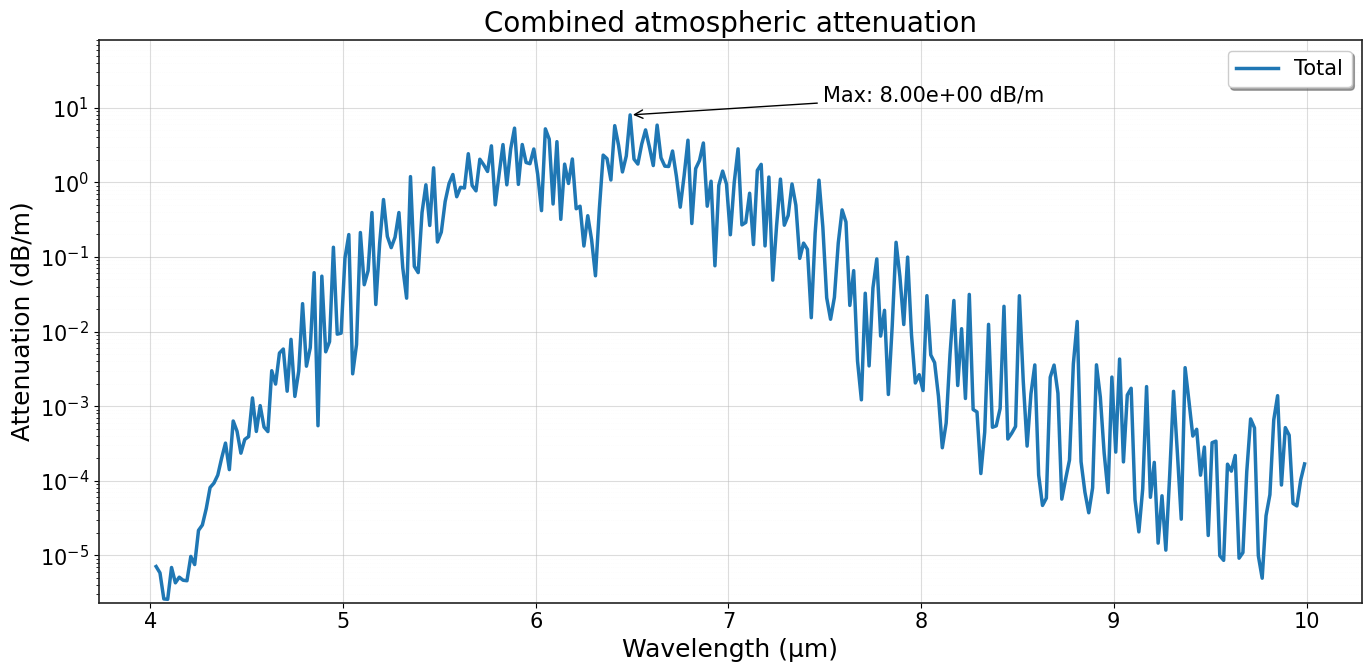

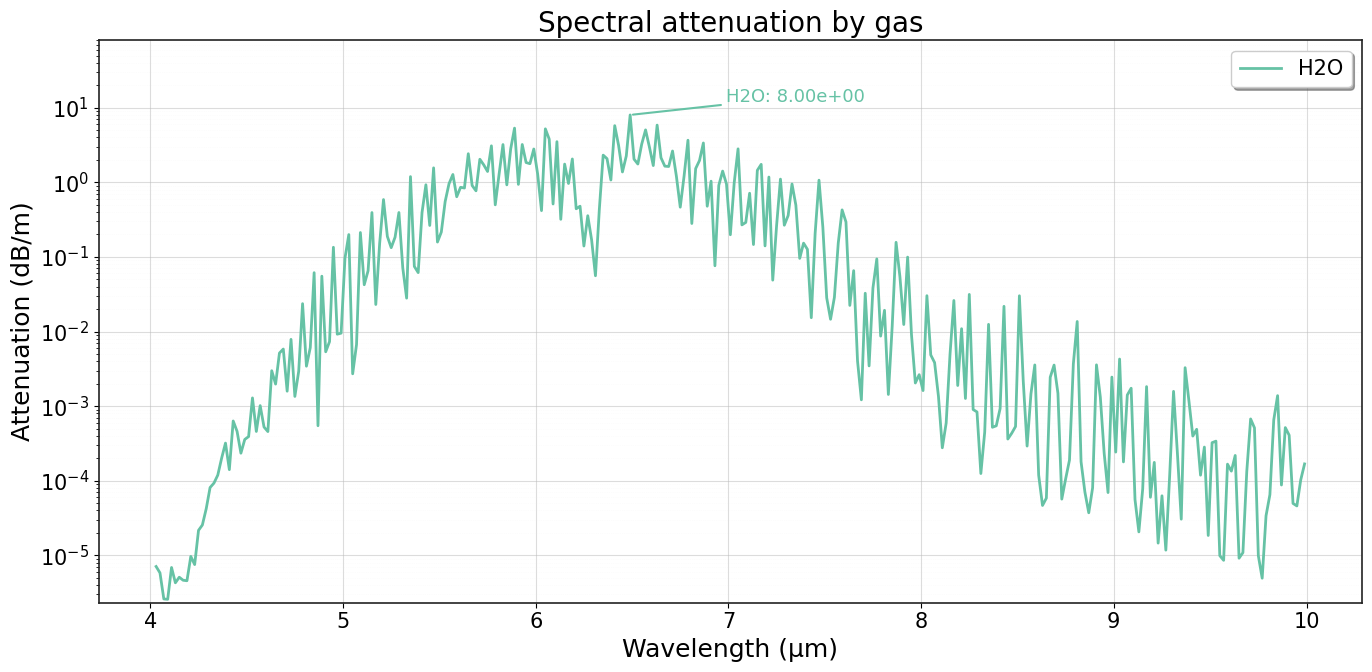

In [6]:
Ptotal = convert_atm(1013, "mbar")
T = 288.2

sp = default_species()
for s in sp:
     if s.name == 'H2O': s.Pmol = 0.0187553713298791
     if s.name == 'CO2': s.Pmol = 0.0003299185788304959
     if s.name == 'O3': s.Pmol = 3.016255613126079e-08
     if s.name == 'N2O': s.Pmol = 3.1992104613866274e-07
     if s.name == 'CO': s.Pmol = 1.4996299037749815e-07
     if s.name == 'CH4': s.Pmol = 1.6995805576116458e-06
     if s.name == 'O2': s.Pmol = 0.2089484332593141
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.01,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.020,
    save_csv=True, outdir='OUT', make_plots=True, 
    att=True, transmission_npy_name='Simulated_Standard_H2O_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['H2O']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

In [7]:


prueba = np.load("SIMULATED/Simulated_Standard_H2O_4-10_1m.npy")                       # (3, 299)
trans  = np.load("GT_PROFE/Transmittance_Standard_H2O_4-10_1m.npy")        # (2, 644299)

lam_tgt = prueba[0]   # centros objetivo (misma resolución que "Prueba_Isotopologos")
lam_src = trans[0]
tau_src = trans[1]


edges = np.empty(lam_tgt.size + 1)
edges[1:-1] = 0.5 * (lam_tgt[:-1] + lam_tgt[1:])
edges[0]    = lam_tgt[0]  - 0.5 * (lam_tgt[1] - lam_tgt[0])
edges[-1]   = lam_tgt[-1] + 0.5 * (lam_tgt[-1] - lam_tgt[-2])


cum = np.concatenate([[0.0], np.cumsum(0.5 * (tau_src[:-1] + tau_src[1:]) * (lam_src[1:] - lam_src[:-1]))])

def cum_at(x):
    return np.interp(x, lam_src, cum)


area = cum_at(edges[1:]) - cum_at(edges[:-1])
tau_ds = area / (edges[1:] - edges[:-1])

valid = (edges[:-1] >= lam_src[0]) & (edges[1:] <= lam_src[-1])
tau_ds[~valid] = np.nan

out = np.vstack([lam_tgt, tau_ds])
np.save("SIMULATED/Transmittance_Standard_H2O_4-10_1m__downsampled_to_Prueba_Isotopologos.npy", out)


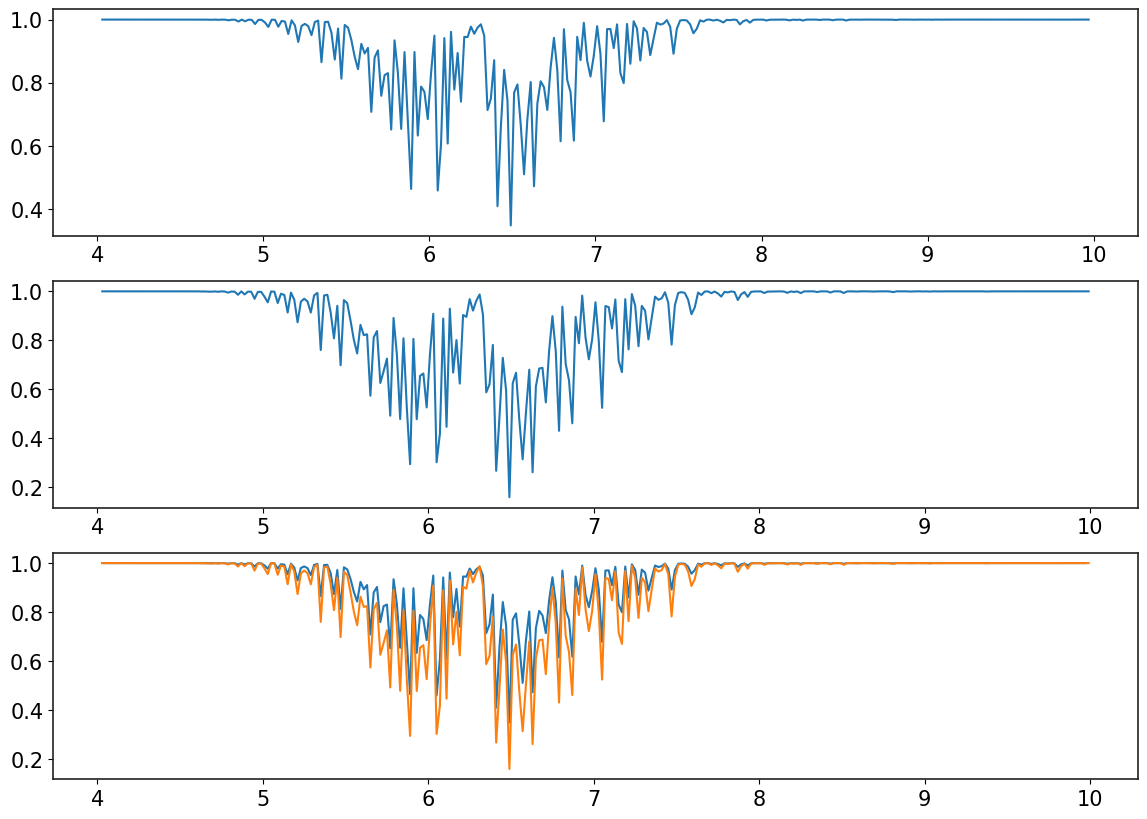

In [15]:
x, y = np.load("SIMULATED/Transmittance_Standard_H2O_4-10_1m__downsampled_to_Prueba_Isotopologos.npy")
sim = np.load("SIMULATED/Simulated_Standard_H2O_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(x, y)
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(x, y)
plt.plot(sim[0], sim[1])

MAE: 0.0342508570659555


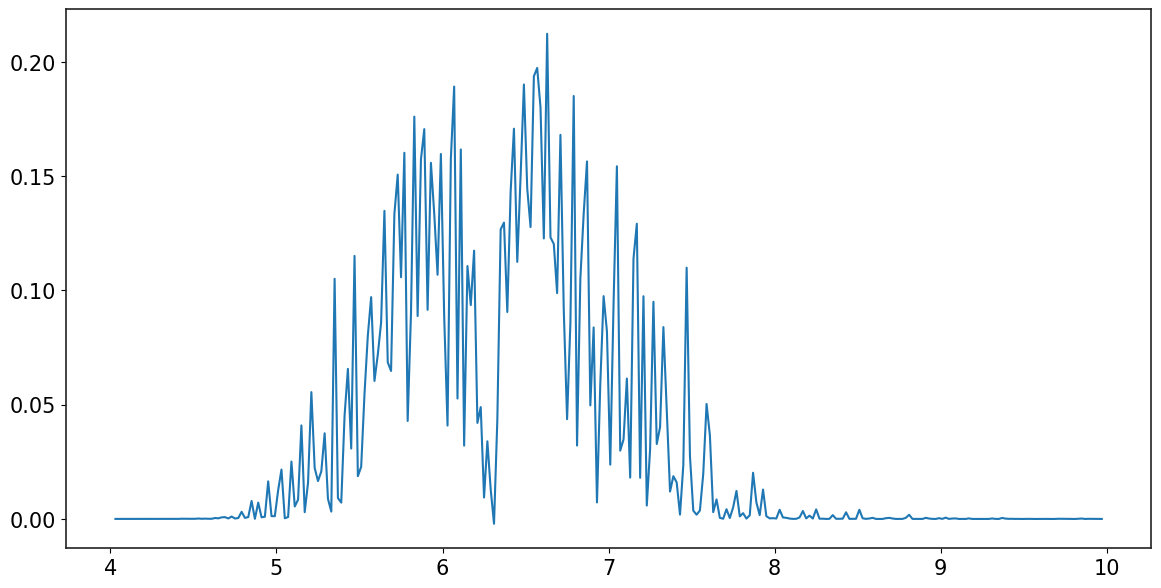

In [12]:
y_gt = y[:-1] #El ultimo valor es nan
y_sim = sim[1][:-1]
x = x[:-1]
x_sim = sim[0][:-1]
residual = (y_gt-y_sim)
mae = np.mean(np.abs(y_gt-y_sim))
plt.figure(figsize=(14,7))
plt.plot(x, residual)
print("MAE:", mae)

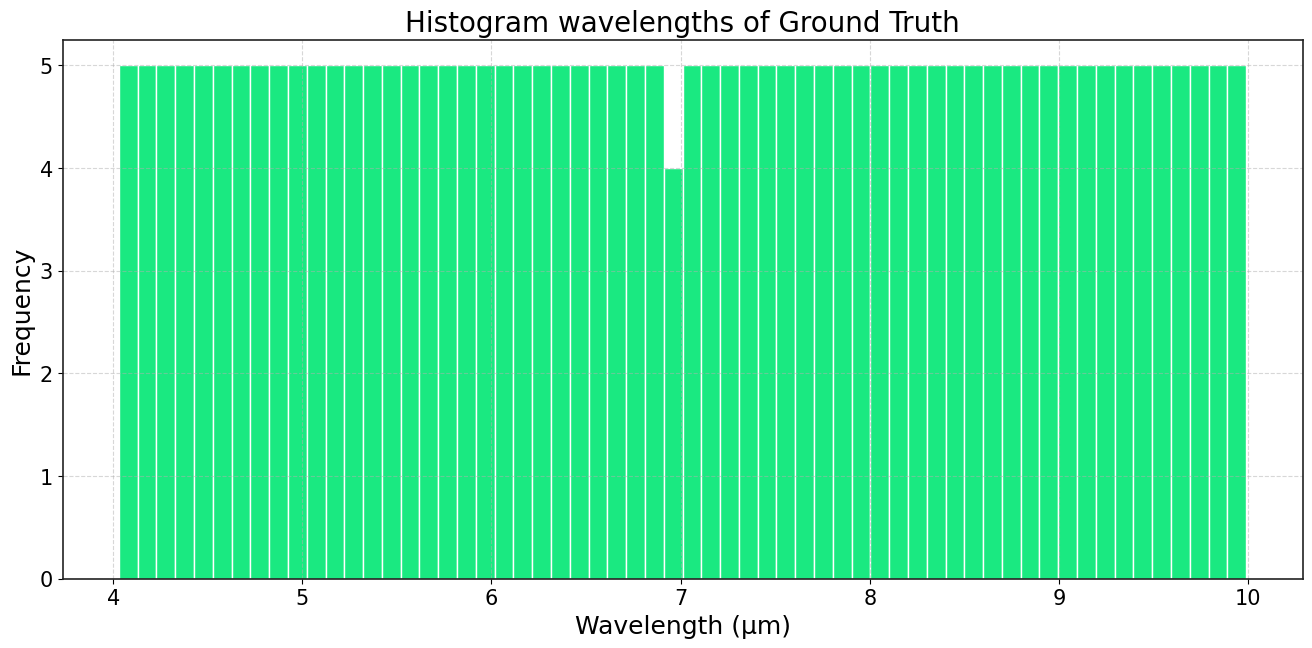

In [16]:
plot_histogram(x,name='Ground Truth')

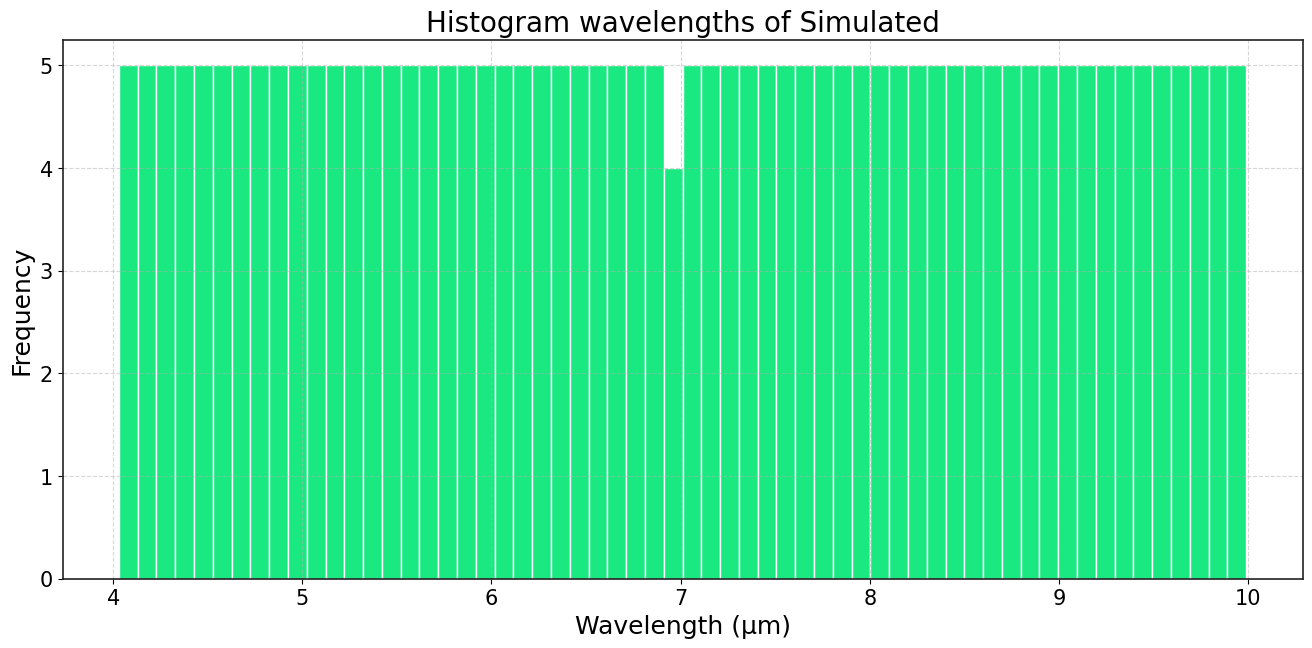

In [14]:
plot_histogram(sim[0],name='Simulated')